# Tutorial on generating slip distributions for Kuril 2025 M8.8 earthquake

This notebooks provides a work flow that generates a stochastic slip distribution similar to the 2025 M8.8 Kuril earthquake on the Kamchatka–Kuril subduction zone. In this tutorial we extract the Kamchatka–Kuril interface from [Slab 2.0](https://www.usgs.gov/data/slab2-a-comprehensive-subduction-zone-geometry-model) and mesh it. As _k223d_ can use a Probablity Density Function (PDF) for influencing where slip is placed on the fault surface, we use the [Finite Fault Slip Distribution](https://earthquake.usgs.gov/earthquakes/eventpage/us6000qw60/finite-fault) (version 5) generated by the USGS to generate a slip PDF. A depth dependent rupture velocity, nucleation location based on the acutal location and the fault surface are defined as input for _k223d_. From this mulitple stochastic slip distributions and the rupture front can be calculated using _k223d_, the slip distributions will honour the original the long wavelength component of the USGS Finite Fault Slip Distribution however with a stochastic short wavelength contribution that changes with each run of _k223d_. 


In this notebook we will:
- generate a mesh using Slab 2.0
- produce a PDF from the USGS Finite Fault Slip Distribution 
- generate self similar slip distributions on the non-planar Kuril subduction interface
- convert the output from _k223d_ to geographical coordinates and in formats for 
[HySEA](https://edanya.uma.es/hysea/models/tsunami-hysea) for use in tsunami simulation or in a geojson for viewing in [QGIS](https://qgis.org/).  the natural output from _k223d_ is a vtk format which is automatically viewable in [Paraview](https://www.paraview.org/)




**Relevant References**: 

Goldberg, D. E., P. Koch, D. Melgar, S. Riquelme, and W. L. Yeck (2022). Beyond the teleseism: Introducing regional seismic and geodetic data into routine USGS finite‐fault modeling. Seismol. Res. Lett., 93(6), 3308–3323. [doi](https://doi.org/10.1785/0220220047)

Hayes, G. P. (2018) Slab2 - A Comprehensive Subduction Zone Geometry Model: U.S. Geological Survey data release. [doi](https://doi.org/10.5066/F7PV6JNV)

Hayes, G. P. (2017). The finite, kinematic rupture properties of great-sized earthquakes since 1990. Earth Planet. Sci. Lett., 468, 94–100. [doi](https://doi.org/10.1016/j.epsl.2017.04.003)

Herrero, A. and Murphy, S. (2018). Self-similar slip distributions on irregular shaped faults. Geophysical Journal International, 213(3), pp.2060-2070. [doi](https://doi.org/10.1093/gji/ggy104)

Murphy, S. and Herrero, A. (2020). Surface rupture in stochastic slip models. Geophysical Journal International, 221(2), pp.1081-1089. [doi](https://doi.org/10.1093/gji/ggaa055)

In [1]:
# data manipulation
import numpy as np
from scipy.interpolate import RBFInterpolator
from sklearn.neighbors import BallTree
from scipy.spatial import ConvexHull
# import pandas as pd

import sys

# Mesh wrangling 
import gmsh
import meshio

# for running k223d
import subprocess

# track time of process
import time

# convert from Geographical coordinates 
import pyproj

#plotting mesh 
import matplotlib.pyplot as plt

import plotly.graph_objs as go
import plotly.express as px
import plotly.io as pio
# if having issues plotting in Jupyter, try switching to the default renderer to png
pio.renderers.default = "png"   # lightweight, no WebView
#pio.renderers.default = "notebook" # generates interactive figures but can cause outputs to become grey with multiple plots in Jupyter


# funciton to download mesh from the USGS Slab2.0 repository 
import rockhound as rh
from rockhound.slab2 import ZONES


### Custom Python modules

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
folder_path = '../../../local_py_scripts'
sys.path.append(folder_path)
from plotting import *
from notebook_utils import *
from fault_scaling import *
import k223d 

In [4]:
kilo = 1000

### Download Subduction Zone from Slab 2.0
The origin of the earthquake is taken from the technical summary provided on the [USGS webpage](https://earthquake.usgs.gov/earthquakes/eventpage/us6000qw60/technical)

> **Note:** The cell below downloads Slab 2.0 data directly from the [USGS ScienceBase](https://www.sciencebase.gov) repository. If the server is temporarily unavailable (e.g. returns a 503 error), this step will fail. Try again later or check the USGS ScienceBase status.

In [5]:
quake_orgin_lat = 52.495 #52.512
quake_orgin_lon = 160.24 #160.324

Mw = 8.8

In [6]:
print("Available zones:", ZONES)


Available zones: {'alaska': {'fname_indicator': 'alu', 'name': 'Alaska'}, 'calabria': {'fname_indicator': 'cal', 'name': 'Calabria'}, 'caribbean': {'fname_indicator': 'car', 'name': 'Caribbean'}, 'cascadia': {'fname_indicator': 'cas', 'name': 'Cascadia'}, 'central_america': {'fname_indicator': 'cam', 'name': 'Central America'}, 'cotabalo': {'fname_indicator': 'cot', 'name': 'Cotabalo'}, 'halmahera': {'fname_indicator': 'hal', 'name': 'Halmahera'}, 'hellenic': {'fname_indicator': 'hel', 'name': 'Hellenic Arc'}, 'himalaya': {'fname_indicator': 'him', 'name': 'Himalaya'}, 'hindu_kush': {'fname_indicator': 'hin', 'name': 'Hindu Kush'}, 'izu_bonin': {'fname_indicator': 'izu', 'name': 'Izu-Bonin'}, 'kamchatka': {'fname_indicator': 'kur', 'name': 'Kamchatka-Kuril Islands-Japan'}, 'kermadec': {'fname_indicator': 'ker', 'name': 'Kermadec'}, 'makran': {'fname_indicator': 'mak', 'name': 'Makran'}, 'manila_trench': {'fname_indicator': 'man', 'name': 'Manila Trench'}, 'muertos_trough': {'fname_indi

In [7]:
# 2. Choose the Kamchatka–Kuril slab zone name (likely "kamchatka_kuril")
zone = "kamchatka"  # adjust if necessary

# 3. Fetch the slab surface geometry grid
grid = rh.fetch_slab2(zone)

In [8]:
# 1. Extract arrays
depth_2d = grid["depth"].values           # shape: (n_lat, n_lon)
lat_1d = grid["latitude"].values          # shape: (n_lat,)
lon_1d = grid["longitude"].values         # shape: (n_lon,)

# 2. Create full coordinate grid
lon_2d, lat_2d = np.meshgrid(lon_1d, lat_1d)

# 3. Flatten the arrays for easier processing and mask NaNs
mask = ~np.isnan(depth_2d)
slab_lat = lat_2d[mask]
slab_lon = lon_2d[mask]
slab_depth = depth_2d[mask]

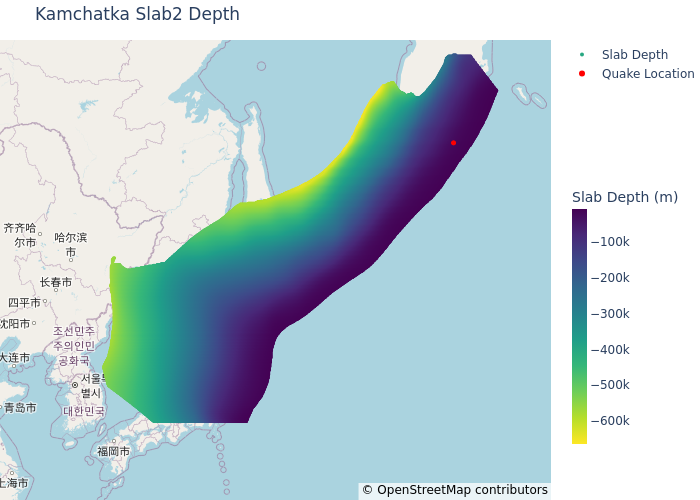

In [9]:
# 4. Plot the full slab depth
fig = go.Figure()

fig.add_trace(go.Scattermap(
    lat=slab_lat,
    lon=slab_lon,
    mode='markers',
    marker=dict(
        size=4,
        color=slab_depth,
        colorscale="Viridis_r",   # reverse so shallow is yellow, deep is dark
        colorbar=dict(title="Slab Depth (m)", x=1.02, thickness=15, len=0.6, y=0.4)
    ),
    name="Slab Depth"
))

fig.add_trace(go.Scattermap(
    lat=[quake_orgin_lat],
    lon=[quake_orgin_lon],
    mode='markers',
    marker=dict(
        size=6,
        color="red"
    ),
    name="Quake Location"
))

# Layout
fig.update_layout(
    map=dict(
        style="open-street-map",
        center=dict(lat=float(np.mean(slab_lat)), lon=float(np.mean(slab_lon))),
        zoom=3
    ),
    title="Kamchatka Slab2 Depth",
    margin={"r":0,"t":40,"l":0,"b":0}
)

# fig.show(renderer="browser")   
fig.show()

## Read in slip inversion data

Slip inversion file `complete_inversion.fsp` can be found in the USGS Finite Fault catalogue, this is a direct link to [page](https://earthquake.usgs.gov/earthquakes/eventpage/us6000qw60/finite-fault) 


In [10]:
quake = read_fsp_combined("complete_inversion.fsp")# extract all subfaults and all segments in one array


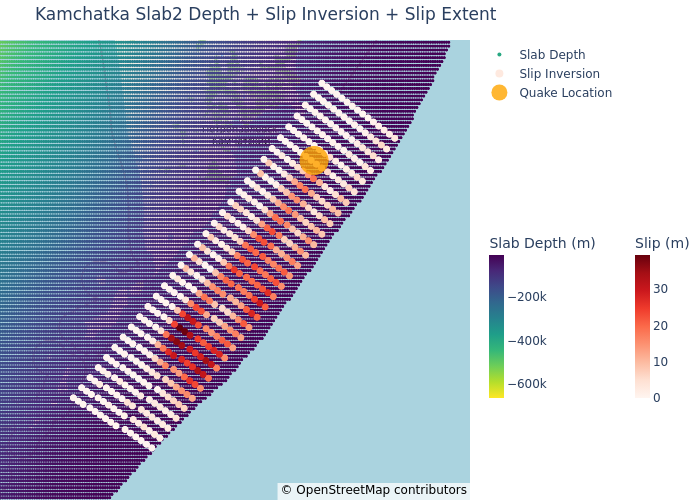

In [11]:
fig = go.Figure()

# Slab2 points (reusing lat_points, lon_points, depth_points from earlier code)
fig.add_trace(go.Scattermap(
    lat=slab_lat,
    lon=slab_lon,
    mode='markers',
    marker=dict(
        size=4,
        color=slab_depth,
        colorscale="Viridis_r",
        colorbar=dict(title="Slab Depth (m)", x=1.02, thickness=15, len=0.4, y=0.4)
    ),
    name="Slab Depth"
))


# # Slip inversion points
fig.add_trace(go.Scattermap(
    lat=quake['lat'],
    lon=quake['lon'],
    mode='markers',
    marker=dict(
        size=8,
        color=quake['slip'],
        colorscale="Reds",
        colorbar=dict(title="Slip (m)", x=1.33, thickness=15, len=0.4, y=0.4),
        cmin=0,
        cmax=max(quake['slip'])
    ),
    name="Slip Inversion"
))

fig.add_trace(go.Scattermap(
    lat=[quake_orgin_lat],
    lon=[quake_orgin_lon],
    mode='markers',
    marker=dict(
        size=30,
        color="#FFA500",
        symbol="circle",
        opacity=0.8,
    ),
    name="Quake Location"
))


# Layout
fig.update_layout(
    map=dict(
        style="open-street-map",
        center=dict(lat=float(np.mean(quake['lat'])), lon=float(np.mean(quake['lon']))),
        zoom=5
    ),
    title="Kamchatka Slab2 Depth + Slip Inversion + Slip Extent",
    margin={"r":0,"t":40,"l":0,"b":0}
)

# fig.show(renderer="browser")   # opens in your default browser, no VSCode WebView
fig.show()

## Extract slab points near earthquake 

In [12]:


inclusion_radius = 20.0 # km 

# Convert slip coordinates to radians
slip_coords_rad = np.radians(np.c_[quake['lat'], quake['lon']])
tree = BallTree(slip_coords_rad, metric='haversine')

# Slab2 coordinates
slab_coords_rad = np.radians(np.c_[slab_lat, slab_lon])

# Nearest neighbour search
dist_rad, idx = tree.query(slab_coords_rad, k=1)
dist_km = dist_rad.flatten() * 6371.0  # Earth radius in km

# Keep only points within 5 km
mask = dist_km <= inclusion_radius
slab_sel_lat = slab_lat[mask]
slab_sel_lon = slab_lon[mask]
slab_sel_depth = slab_depth[mask]

print(f"Kept {mask.sum()} slab points within 20 km of slip model")


Kept 5862 slab points within 20 km of slip model


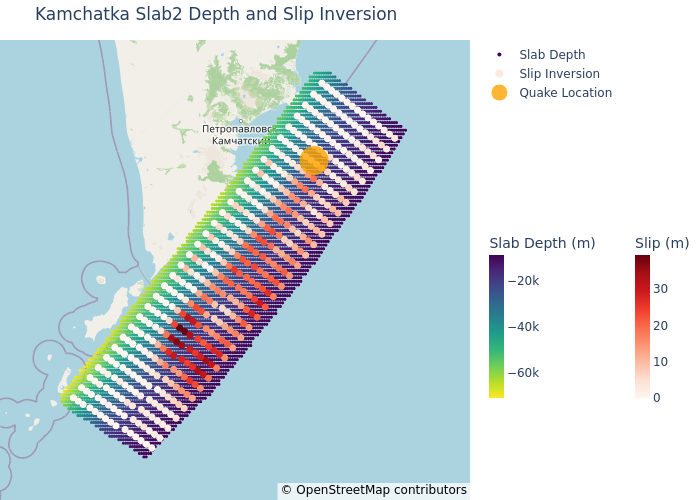

In [13]:
fig = go.Figure()

# Slab2 points (reusing lat_points, lon_points, depth_points from earlier code)
fig.add_trace(go.Scattermap(
    lat=slab_sel_lat,
    lon=slab_sel_lon,
    mode='markers',
    marker=dict(
        size=4,
        color=slab_sel_depth,
        colorscale="Viridis_r",
        colorbar=dict(title="Slab Depth (m)", x=1.02, thickness=15, len=0.4, y=0.4),
    ),
    name="Slab Depth"
))


# Slip inversion points
fig.add_trace(go.Scattermap(
    lat=quake['lat'],
    lon=quake['lon'],
    mode='markers',
    marker=dict(
        size=8,
        color=quake['slip'],
        colorscale="Reds",
        colorbar=dict(title="Slip (m)", x=1.33, thickness=15, len=0.4, y=0.4),
        cmin=0,
        cmax=max(quake['slip'])
    ),
    name="Slip Inversion"
))

fig.add_trace(go.Scattermap(
    lat=[quake_orgin_lat],
    lon=[quake_orgin_lon],
    mode='markers',
    marker=dict(
        size=30,
        color="#FFA500",
        symbol="circle",
        opacity=0.8,
    ),
    name="Quake Location"
))


# Layout
fig.update_layout(
    map=dict(
        style="open-street-map",
        center=dict(lat=float(np.mean(quake['lat'])), lon=float(np.mean(quake['lon']))),
        zoom=5
    ),
    title="Kamchatka Slab2 Depth and Slip Inversion",
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

Happy with the coordinates that are being kept so we can clear Slab2.0 variables.

In [14]:
del dist_rad ,dist_km, slab_coords_rad,slip_coords_rad, tree,slab_lat, slab_lon,slab_depth

## Convert to UTM coordinates 
- convert both the Slab2.0 and the slip inversion to UTM coordinates 

In [15]:
# First convert Slab 2.0 to UTM coordinates 
utm_zone = str(int(np.floor((np.mean(slab_sel_lon)  + 180) / 6 ) % 60) + 1)
if len(utm_zone) == 1:
    utm_zone = '0'+utm_zone
print('UTM Zone:     ',utm_zone)


UTM Zone:      57


In [16]:
# Parameters use in the script
# the first two relate to the converting lat/lon to utm and a geodesic distance
P = pyproj.Proj(proj='utm', zone=utm_zone, ellps='WGS84', preserve_units=True)    # took utm 

Convert section of Slab 2.0 to UTM coordinates 

In [17]:
slab_x, slab_y = P(slab_sel_lon, slab_sel_lat)
ref_x = 0. # UTM_x[0]
ref_y = 0. # UTM_y[0]
slab_x = np.array(slab_x)/kilo#-ref_x (convert m → km first if still in meters)
slab_y = np.array(slab_y)/kilo#-ref_y (convert m → km first if still in meters)
slab_z = slab_sel_depth/kilo
slab_points_km = np.c_[slab_x, slab_y]  # shape (n_points, 2)


Convert USGS slip distribution to UTM coordinates

In [18]:
slip_x, slip_y = P(quake['lon'], quake['lat'])
slip_x = np.array(slip_x)/kilo#-ref_x (convert m → km first if still in meters)
slip_y = np.array(slip_y)/kilo#-ref_y (convert m → km first if still in meters)
slip_points_km = np.c_[slip_x, slip_y]  # in km


Convert Earthquake location to UTM coordinates

In [19]:
quake_origin_x, quake_origin_y = P(quake_orgin_lon, quake_orgin_lat)
quake_origin_x = quake_origin_x/kilo
quake_origin_y = quake_origin_y/kilo


# Start creating mesh based on Slab 2.0 mesh
We need to generate a higher resolution triangular mesh for _k223d_. This will be done in a workflow which has the steps
1) Create an outer boundary to fault points 
2) Create a 2d mesh based on x and y coordinates 
3) Add depth to mesh based on interpolated depth field from Slab 2.0 dataset

In [20]:


# Stack x, y into points array
points = np.column_stack((slab_x, slab_y))

# Compute convex hull
hull = ConvexHull(points)

# Get boundary points
boundary_points = points[hull.vertices]

# Boundary point indices (into original array) in CCW order
boundary_indices = hull.vertices

In [21]:
# --- Check if all points are inside the hull ---
inside = True
for eq in hull.equations:
    # eq = [a, b, c] for ax + by + c = 0
    a, b, c = eq
    # If any point violates the <= 1e-12 tolerance, it's outside
    if np.any(a * points[:, 0] + b * points[:, 1] + c > 1e-12):
        inside = False
        break

if inside:
    print("✅ All points are inside the convex hull.")
else:
    print("⚠️ Some points are outside the convex hull.")

✅ All points are inside the convex hull.


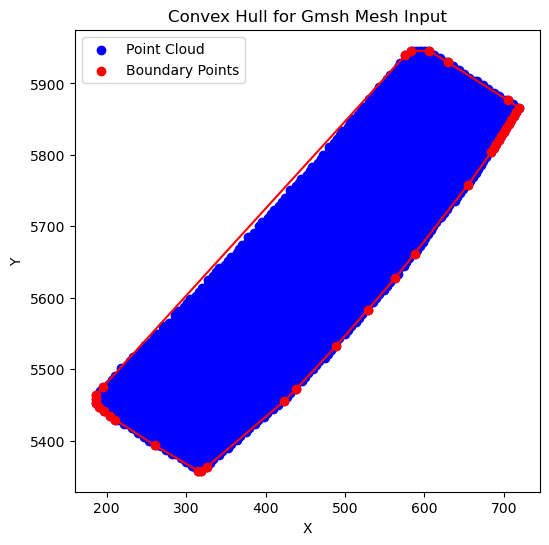

In [22]:
# --- Create connectivity array for Gmsh ---
edges = []
for i in range(len(boundary_indices)):
    p1 = boundary_indices[i]
    p2 = boundary_indices[(i + 1) % len(boundary_indices)]
    edges.append([p1, p2])  # indices into original point array

edges = np.array(edges)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], color="blue", label="Point Cloud")
plt.scatter(points[boundary_indices, 0], points[boundary_indices, 1],
            color="red", zorder=5, label="Boundary Points")

# Draw edges
for e in edges:
    plt.plot([points[e[0], 0], points[e[1], 0]],
             [points[e[0], 1], points[e[1], 1]], 'r-')

plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Convex Hull for Gmsh Mesh Input")
plt.show()

Next step is to generate a 2d mesh (x,y) not accounting for depth

In [23]:
points_2d = points[:, :2]
mesh_size = 15.0  # control mesh resolution (in km)

# --- Initialize Gmsh ---
gmsh.initialize()
gmsh.clear() 
gmsh.model.add("point_cloud_boundary")


# Add points to Gmsh model
gmsh_points = []
for idx in boundary_indices:
    x, y = points_2d[idx]
    gmsh_points.append(
        gmsh.model.geo.addPoint(float(x), float(y), 0.0, mesh_size)
    )

# Add lines connecting points
gmsh_lines = []
n = len(gmsh_points)
for i in range(n):
    p1 = gmsh_points[i]
    p2 = gmsh_points[(i + 1) % n]  # wrap around
    gmsh_lines.append(gmsh.model.geo.addLine(p1, p2))


# Create line loop and surface
loop = gmsh.model.geo.addCurveLoop(gmsh_lines)
gmsh.model.geo.addPlaneSurface([loop])    

# Synchronize so we can see geometry in GUI
gmsh.model.geo.synchronize()

gmsh.model.mesh.generate(2)   # put as 3 as we are generating a 3d mesh
# Save mesh
gmsh.write("step2_flat_mesh.vtk")

gmsh.finalize()

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 20%] Meshing curve 6 (Line)
Info    : [ 20%] Meshing curve 7 (Line)
Info    : [ 20%] Meshing curve 8 (Line)
Info    : [ 30%] Meshing curve 9 (Line)
Info    : [ 30%] Meshing curve 10 (Line)
Info    : [ 30%] Meshing curve 11 (Line)
Info    : [ 40%] Meshing curve 12 (Line)
Info    : [ 40%] Meshing curve 13 (Line)
Info    : [ 40%] Meshing curve 14 (Line)
Info    : [ 40%] Meshing curve 15 (Line)
Info    : [ 50%] Meshing curve 16 (Line)
Info    : [ 50%] Meshing curve 17 (Line)
Info    : [ 50%] Meshing curve 18 (Line)
Info    : [ 60%] Meshing curve 19 (Line)
Info    : [ 60%] Meshing curve 20 (Line)
Info    : [ 60%] Meshing curve 21 (Line)
Info    : [ 60%] Meshing curve 22 (L

### Interpolate depth onto cells based on Slab2.0

In [24]:
# Load the mesh you just created
gmsh.initialize()
gmsh.open("step2_flat_mesh.vtk")

# Get mesh nodes
node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
coords = np.array(node_coords).reshape(-1, 3)

# Fit RBF model
rbf = RBFInterpolator(points_2d, slab_z, neighbors=10)  # default is thin plated spline, 

# Predict Z at mesh nodes
z_interp = rbf(coords[:, :2])

# Replace Z in coords
coords[:, 2] = z_interp

# Update mesh nodes in Gmsh
for tag, new_coord in zip(node_tags, coords):
    gmsh.model.mesh.setNode(tag, new_coord.tolist(), [])

# Save updated 3D mesh
gmsh.write("step3_3d_mesh.vtk")
gmsh.finalize()

print("✅ 3D mesh written to step3_3d_mesh.vtk")


Info    : Reading 'step2_flat_mesh.vtk'...
Info    : Reading 846 points
Info    : Reading 1726 cells
Info    : Done reading 'step2_flat_mesh.vtk'
Info    : Writing 'step3_3d_mesh.vtk'...
Info    : Done writing 'step3_3d_mesh.vtk'
✅ 3D mesh written to step3_3d_mesh.vtk


## Pre-processing for k223d : slip probability density function and rupture velocity
Now that we have a mesh we will use the USGS Finite Fault Slip Distribution to generate a probablity density function which will be used to decide where to place patches of slip randomly on the slab. Additionally the rupture velocity and nucleation location in relation to the mesh will be added. 


In [25]:
# Fit RBF model
slip_fn = RBFInterpolator(slip_points_km, quake['slip'], neighbors=10, kernel='linear')  # interoplated slip values at the mesh nodes, 
#rupt_fn = RBFInterpolator(slip_points_km, quake['trup'], neighbors=10, kernel='linear')  # interpolate rupture times at the mesh nodes



In [26]:
new_x,new_y,new_z,new_cells = extract_mesh('step3_3d_mesh.vtk')
new_points = np.transpose([new_x,new_y,new_z])



Info    : Reading 'step3_3d_mesh.vtk'...
Info    : Reading 846 points
Info    : Reading 1726 cells
Info    : Done reading 'step3_3d_mesh.vtk'
number of nodes      846
number of elements     1564


x,y barycentre of cell will be used to calculate slip pdf for each cells

In [27]:
cell_bary_x = np.average(new_x[new_cells],axis=1)
cell_bary_y = np.average(new_y[new_cells],axis=1)
cell_bary = np.c_[cell_bary_x,cell_bary_y]

# Predict Z at mesh nodes
slip_i = slip_fn(cell_bary)      # this can generate negative slip values so we will rescale the slip to fit the original slip range

print('interpolated slip....', np.min(slip_i), np.max(slip_i))
mesh_slip = (slip_i-np.min(slip_i))/(np.max(slip_i)-np.min(slip_i)) * (np.max(quake['slip']) - np.min(quake['slip'])) + np.min(quake['slip'])  

print('corrected slip....', np.min(mesh_slip), np.max(mesh_slip))


interpolated slip.... -3.1930294818351577 37.82963193981047
corrected slip.... 0.0022 39.3435


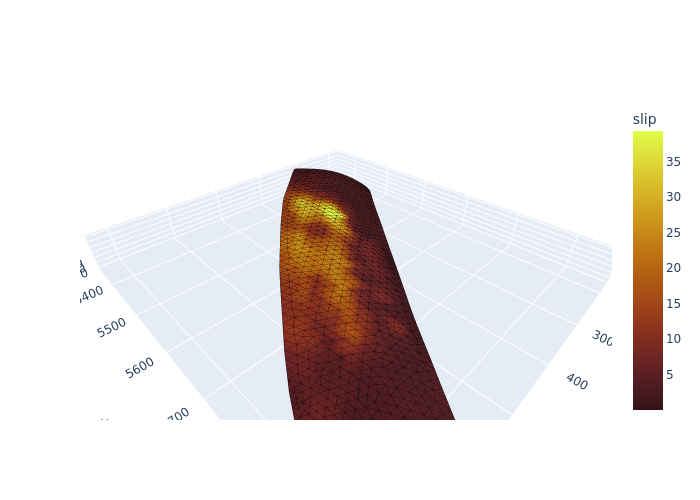

In [28]:
plot_mesh_cell(new_cells,new_points,mesh_slip,'slip')

create a pdf from the slip distribution..

In [29]:
slip_pdf = mesh_slip/np.sum(mesh_slip)

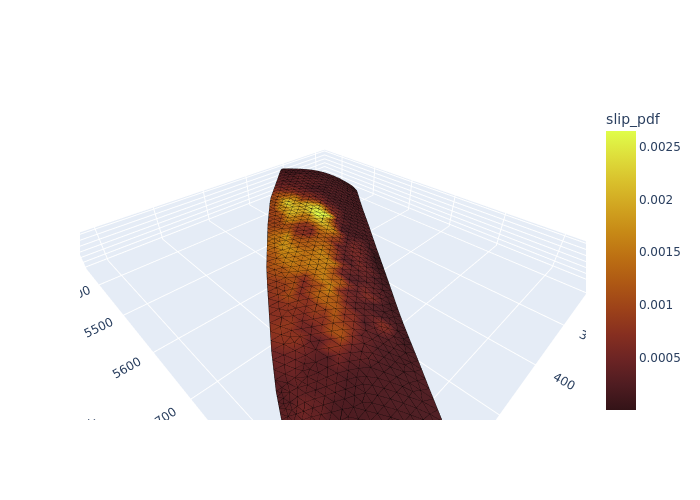

In [30]:
plot_mesh_cell(new_cells,new_points,slip_pdf,'slip_pdf')

## Add rupture velocity 

In [31]:
rupt_vel  = 2000.  # Set the initial velocity at the surface [m/s]
rupt_grad = 0.25   # Set the depth dependent velocity gradient [/s] 

In [32]:
ncells,_ = np.shape(new_cells) 

# set velocity for each cell
cell_vel = np.zeros(ncells)
for i in range(ncells):
    c_id = new_cells[i]
    # cell_vel[i] = rupt_vel    

    # use the mean depth of each cell
    mean_depth = np.abs(np.mean(new_z[c_id]))   
    cell_vel[i] = rupt_vel  + rupt_grad*(mean_depth)

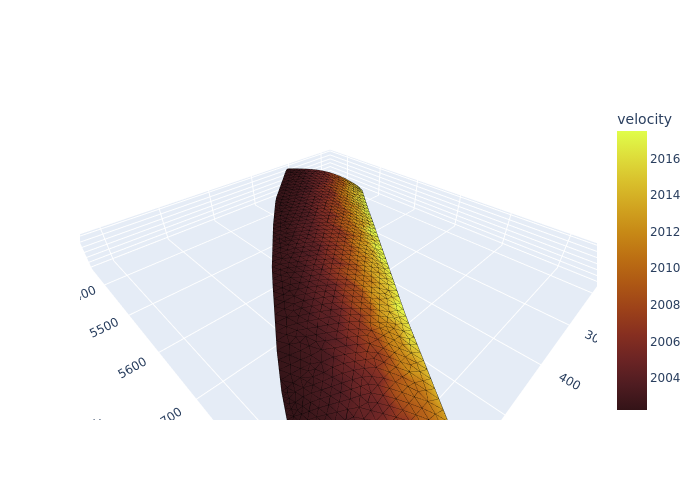

In [33]:
plot_mesh_cell(new_cells,new_points,cell_vel,'velocity')

### Nucleation location of earthquake  
To decide where to pick for the nucleation for the earthquake, we use the location given earlier from the INGV catalogue. It is also possible to decide your own location. To do this change the quake_x and quake_y values. Always check that the _assign_nucleation_location_ does not give an error due to the quake_x and quake_y values being outside of the mesh area. 


In [34]:
# plot_mesh(new_cells,new_points)
# only using x,y coordinates for defining earthquake initiation 
# assuming rupture velocity is constant within nucleation cell
itime = assign_nucleation_location(quake_origin_x,quake_origin_y,new_x,new_y,new_z,new_cells,cell_vel)

Source is in cell 804
Initial travel time on starting cell edges: [0.00527792 0.00183992 0.00552338]


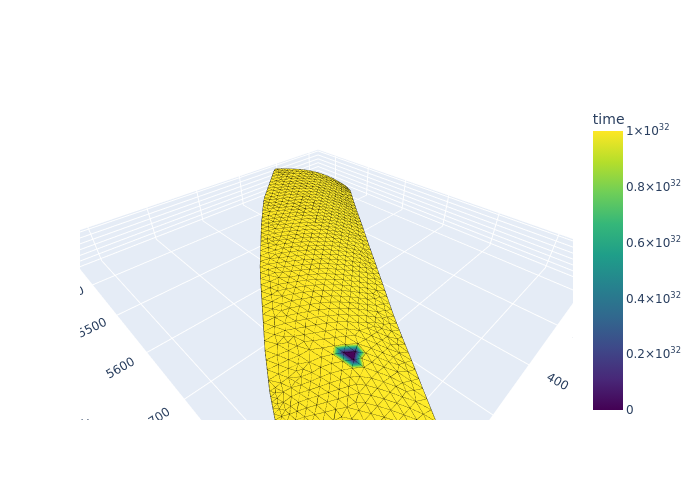

In [35]:
plot_mesh_node(new_cells,new_points,itime,'time')

## Asign surface rupture 
First we look at the depth range on the fault from this choose if we wish to set the upper nodes as a 'surface' to cause large slip at the surface. In this case we make an assumption that grid points abouve -9.8km is at the 'surface', other techinques could be used to better account for the surface (e.g. extend the slab to the surface).

Alternatively it could be assumed that there is no surface rupture therefore none of the grid need be designated as being on the surface. In this case slip along the upper board will not be mirrored but will end up being tapered to zero at the boundary. 

In [36]:
print('fault depth range (km):    ',np.min(new_z),'to ' ,np.max(new_z))

fault depth range (km):     -72.42170457359934 to  -8.898145675659178


In [37]:
# set surface rupture depth 
surface_depth = -9.8 
new_nnodes = len(new_z)
surface_nodes =  np.zeros(new_nnodes,dtype=int)
for i in range(new_nnodes):
    if new_z[i] >= surface_depth:
        surface_nodes[i] = 1
print('number of surface nodes.....',np.sum(surface_nodes))



number of surface nodes..... 74


In [38]:
# check that no cell has 3 surface nodes, if that is the case remove the deepest node from the surface nodes list 
for i in range(ncells):
    c_id = new_cells[i]
    surface_in_cell = np.sum(surface_nodes[c_id])
    if surface_in_cell == 3:
        print('cell',i,'has',surface_in_cell,'surface nodes, removing deepest node from list')
        # remove deepest node from surface cell
        deepest_node = np.argmin(new_z[c_id])
        surface_nodes[c_id[deepest_node]] = 0
print('number of surface nodes.....',np.sum(surface_nodes))


cell 60 has 3 surface nodes, removing deepest node from list
cell 119 has 3 surface nodes, removing deepest node from list
cell 216 has 3 surface nodes, removing deepest node from list
cell 553 has 3 surface nodes, removing deepest node from list
cell 951 has 3 surface nodes, removing deepest node from list
cell 990 has 3 surface nodes, removing deepest node from list
cell 1194 has 3 surface nodes, removing deepest node from list
cell 1253 has 3 surface nodes, removing deepest node from list
cell 1266 has 3 surface nodes, removing deepest node from list
cell 1275 has 3 surface nodes, removing deepest node from list
cell 1276 has 3 surface nodes, removing deepest node from list
cell 1306 has 3 surface nodes, removing deepest node from list
cell 1365 has 3 surface nodes, removing deepest node from list
cell 1415 has 3 surface nodes, removing deepest node from list
cell 1448 has 3 surface nodes, removing deepest node from list
cell 1463 has 3 surface nodes, removing deepest node from list

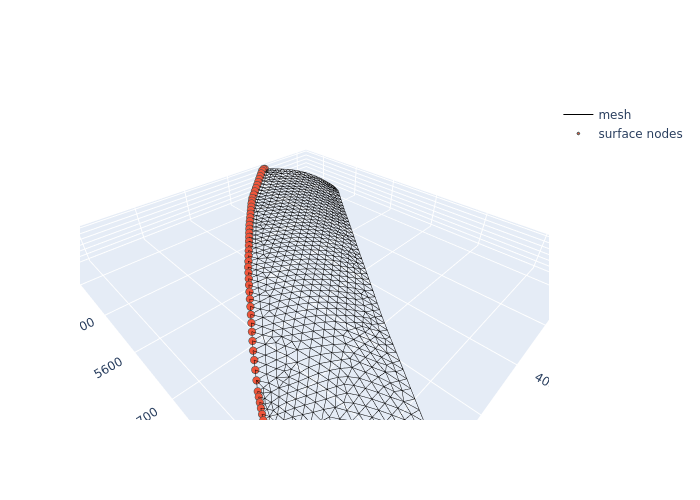

In [39]:
plot_highlight_nodes(new_cells,new_points,surface_nodes,'surface nodes')


### Prepare mesh for k223d


In [40]:
new_points_m = new_points*1000.  # convert back to meters for writing to file

# Run _k223d_ inside the notebook
Two examples are provide, in the first only a slip distribution is generated assume no surface rupture, in the second surface rupture is assumed and the rupture traveltime on the fault plane is calculated also

In [41]:
slip,_ = k223d.compute_source(new_points_m,new_cells, mw=Mw,  pdf=slip_pdf )
# itime,slip_pdf,surface_nodesvelocity=cell_vel,

 build_mesh_geometry


Total fault area:        1.2535E+11 m^2
Estimated fault width:  212739.58 m
 calculate distance to border
 calculate distance between all nodes


 construct slip distribution


 using max of pdf fn for location of first subevent 
total slipping area        1.2535E+11
average slip:                5.31 m
moment of event            1.9953E+22
Moment magnitude of event    8.80


Plot slip distribution

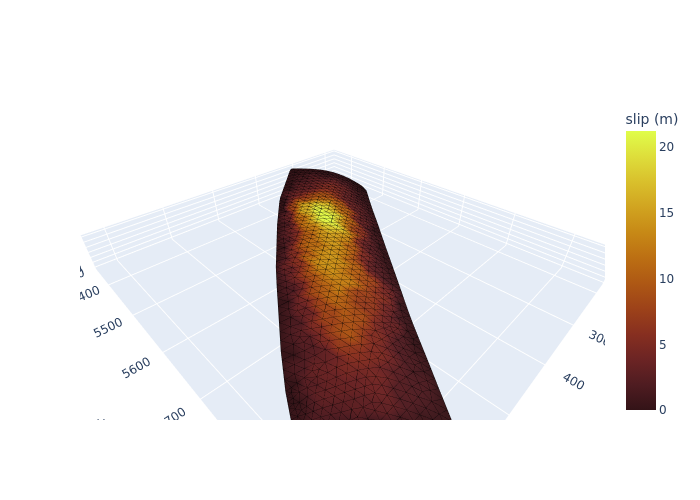

In [42]:
plot_mesh_cell(new_cells,new_points,slip,'slip (m)')

Calculate slip and rupture time 

In [59]:
slip,rupt_time = k223d.compute_source(new_points_m,new_cells, mw=Mw,  pdf=slip_pdf,velocity=cell_vel,time=itime,surface_nodes=surface_nodes)


 build_mesh_geometry


Total fault area:        1.2535E+11 m^2
Estimated fault width:  212739.58 m
 calculate distance to border
 calculate distance between all nodes


 construct slip distribution


 using max of pdf fn for location of first subevent 


 calculate rupture time
 starting trilateration.....


total slipping area        1.2535E+11
average slip:                5.31 m
moment of event            1.9953E+22
Moment magnitude of event    8.80


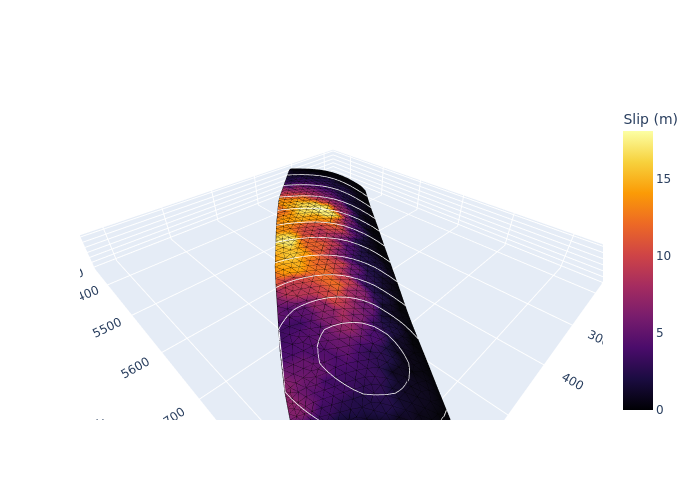

In [60]:
plot_mesh_cell_node(new_cells, new_points, slip,rupt_time, 'Slip (m)', contours=True, n_contours=10)

In [61]:
write2fmt(new_points_m, new_cells, "quake_mesh5", fmt='vtk', rake=90.0, slip=slip, time=rupt_time, slip_pdf=slip_pdf, surface_nodes=surface_nodes)

VTK file created: quake_mesh5.vtk


## Convert to Geographical Coordinates 

In [54]:
utm_zone = 57  # this should be the same as the one used for converting lat/lon to utm coordinates, if using notebook in one go, no need to run this cell. 
P = pyproj.Proj(proj='utm', zone=utm_zone, ellps='WGS84', preserve_units=True)    # took utm 

In [55]:
slip_lon, slip_lat = P(new_points_m[:,0], new_points_m[:,1], inverse=True)
nodes = np.transpose([slip_lon, slip_lat,new_points_m[:,2]]) 

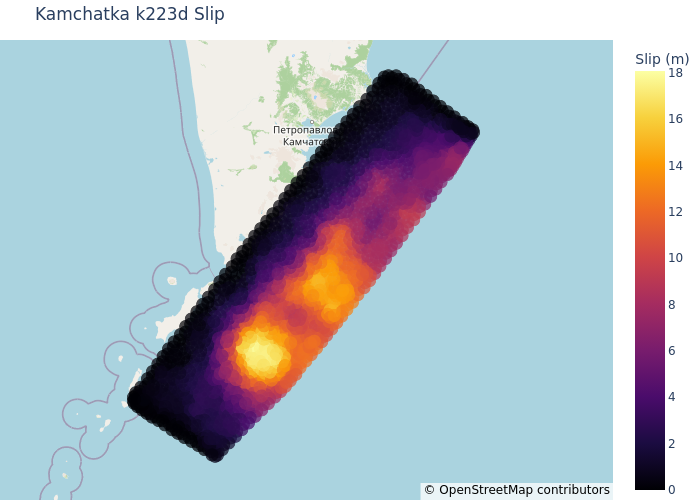

In [56]:
geo_mesh(new_cells, nodes, slip, 'Slip (m)', marker_size=14,opacity_value=0.7)

# Output for QGIS
Output a geojson file with geographical coordinates so the slip and rupture time can be viewed in QGIS. 

In [57]:
write2fmt(nodes, new_cells, "quake_mesh", fmt='qgis', rake=90.0, slip=slip, time=rupt_time)

QGIS GeoJSON file created: quake_mesh.geojson


To find out more about the write2fmt and the output options:

In [58]:
help(write2fmt)

Help on function write2fmt in module notebook_utils:

write2fmt(nodes, cells, slip, time, file_name, fmt='qgis', rake=0.0)
    Write fault mesh data to file in the format specified by fmt.
    nodes:      mesh nodes numpy array  [lon, lat, depth]
    cells:      numpy integer array linking nodes to cells
    slip:       numpy array with slip for each cell
    time:       numpy array with rupture time for each node
    file_name:  output file name (extension is set automatically per format)
    fmt:        output format — 'qgis' (default) or 'hysea'
    rake:       rake angle [deg], used only for fmt='hysea'

